# Monthly Mean Net Shortwave heat flux: ACCESS vs Papa
### As part of the flux components, this notebook produces a figure comparing the monthly mean net shortwave flux climatology of three different Access-om2 resolutions versus observational data from PAPA ocean station

In [1]:
import os
import re
import sys
import glob
import time
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from xarray.coding.times import CFDatetimeCoder

time_coder = CFDatetimeCoder(use_cftime=True)

In [2]:
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38989 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/38989/status,
Dashboard: /proxy/38989/status,Workers: 1
Total threads: 1,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37245,Workers: 0
Dashboard: /proxy/38989/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37127,Total threads: 1
Dashboard: /proxy/39473/status,Memory: 63.00 GiB
Nanny: tcp://127.0.0.1:40783,


In [3]:
print("Starting ACCESS-OM2 and Papa sensible heat flux analysis.")
sys.stdout.flush()

catalog = intake.cat.access_nri

# -------------------------------------------------------------
# Date of interest
# -------------------------------------------------------------
start_date = np.datetime64("2010-01-01")
end_date = np.datetime64("2023-12-31")

# -------------------------------------------------------------
# Variable and degrees of interest in ACCESS-OM2
# -------------------------------------------------------------
var = "sens_heat"
experiments = [
    "1deg_jra55_iaf_omip2_cycle6",
    "025deg_jra55_iaf_omip2_cycle6",
    ["01deg_jra55v140_iaf_cycle4", "01deg_jra55v140_iaf_cycle4_jra55v150_extension"],
]

# Papa
PAPA_DIR  = "/g/data/jk72/ob1561"
papa_file = os.path.join(PAPA_DIR, "qsen50n145w_hr.cdf")
papa_var  = "QS_138"

# -------------------------------------------------------------
# Region of interest (unchanged)
# -------------------------------------------------------------
region_lat = np.array([49, 51])      # narrow 2° band around 50°N
region_lon = np.array([213, 217])# xt_ocean, E     # -> [-215, -210]
region_lon = region_lon - 360
region = [region_lat, region_lon]

Starting ACCESS-OM2 and Papa sensible heat flux analysis.


In [4]:
#----------------------------------------------------------------------------------------------
# This section collects all the experiment / degrees / variable paths
#----------------------------------------------------------------------------------------------
print(f'Processing ACCESS {var} data...')
sys.stdout.flush()
    

path_dict = {}

catalogs = []

for exp in experiments:

    if isinstance(exp, list):  # both tenth degree + extention
        merged_name = exp[0]   
        path_dict[merged_name] = []
    
        for subexp in exp:
            filtered = catalog[subexp].search(
                variable=var,
                frequency='1mon',
                realm='ocean',
            )
            df = filtered.df
            df['start_date'] = pd.to_datetime(df['start_date'])
            df['end_date']   = pd.to_datetime(df['end_date'])
    
            df = df[
                (df['start_date'] >= np.datetime64("2010-01-01")) &
                (df['end_date']   <= np.datetime64("2023-12-31"))
            ]
    
            file_list = df['path'].tolist()
            path_dict[merged_name].extend(file_list)
    
        print(f"{merged_name}: {len(path_dict[merged_name])} files")
    
    else:  
        path_dict[exp] = []
        filtered = catalog[exp].search(
            variable=var,
            frequency='1mon',
            realm='ocean',
        )
        df = filtered.df
        df['start_date'] = pd.to_datetime(df['start_date'])
        df['end_date']   = pd.to_datetime(df['end_date'])
    
        df = df[
            (df['start_date'] >= np.datetime64("2010-01-01")) &
            (df['end_date']   <= np.datetime64("2023-12-31"))
        ]
    
        file_list = df['path'].tolist()
        path_dict[exp].extend(file_list)
    
        print(f"{exp}: {len(file_list)} files")
    

Processing ACCESS sens_heat data...
1deg_jra55_iaf_omip2_cycle6: 8 files
025deg_jra55_iaf_omip2_cycle6: 8 files
01deg_jra55v140_iaf_cycle4: 167 files


In [5]:
#----------------------------------------------------------------------------------------------
# Collect ACCESS data
#----------------------------------------------------------------------------------------------

exp_heat_flux = {} #dict for each deg

start = time.time()

exp_heat_flux = {}

experiments = [
    "1deg_jra55_iaf_omip2_cycle6",
    "025deg_jra55_iaf_omip2_cycle6",
    "01deg_jra55v140_iaf_cycle4"
]

for exp in experiments:
    print(f"Start collecting {var} {exp} data for ACCESS.")
    sys.stdout.flush()
    start = time.time()

    path_list = path_dict[exp]

    ds = xr.open_mfdataset(
        path_list,
        combine="nested",
        concat_dim="time",
        data_vars="minimal",
        coords="minimal",
        decode_timedelta=True
    )

    # Only sort time for tenth deg 
    if "01deg" in exp:
        ds = ds.sortby("time")

    # Slice region and time
    heat_flux = ds[var].sel(
        time=slice(start_date, end_date),
        yt_ocean=slice(region[0][0], region[0][1]),
        xt_ocean=slice(region[1][0], region[1][1])
    ).mean(dim=["yt_ocean", "xt_ocean"])

    ds.close()

    # Keep units
    units = heat_flux.attrs.get("units", "")
    heat_flux.attrs["units"] = units

    grp = heat_flux.groupby("time.month")
    monthly_mean = grp.mean("time", skipna=True)
    monthly_std  = grp.std("time", skipna=True)
    monthly_n    = grp.count("time")
    monthly_sem  = monthly_std / np.sqrt(monthly_n)
    
    exp_heat_flux[exp] = {
    "monthly_mean": monthly_mean,
    "monthly_sem": monthly_sem
}

    end = time.time()
    print(f"Finished collecting {var} data for ACCESS.")
    sys.stdout.flush()
    print(f"Execution time: {(end - start)/60:.2f} minutes")
    sys.stdout.flush()


Start collecting sens_heat 1deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting sens_heat data for ACCESS.
Execution time: 0.12 minutes
Start collecting sens_heat 025deg_jra55_iaf_omip2_cycle6 data for ACCESS.
Finished collecting sens_heat data for ACCESS.
Execution time: 0.04 minutes
Start collecting sens_heat 01deg_jra55v140_iaf_cycle4 data for ACCESS.
Finished collecting sens_heat data for ACCESS.
Execution time: 0.35 minutes


In [10]:
#------------------------------------------------------------------
# Read and collect data for Papa sensible heat flux
#------------------------------------------------------------------

print('Processing Papa sensible heat flux data...')
sys.stdout.flush()

# Open the Papa file
ds_papa = xr.open_dataset(papa_file)

# Raw variable
papa_raw = ds_papa[papa_var]
print("papa_var =", papa_var)
print("units =", papa_raw.attrs.get("units"))
print("long_name =", papa_raw.attrs.get("long_name"))
print("min/max (raw) =", float(papa_raw.min()), float(papa_raw.max()))

fill = papa_raw.attrs.get('missing_value', 1e35)

print("Papa raw min/max:", float(papa_raw.min()), float(papa_raw.max()))
print("Fill value:", fill)

# Mask out the fill value (1e35) so it does not ruin the scale
papa_clean = papa_raw.where(papa_raw != fill)

# Monthly climatology (still (month, depth, lat, lon))
grp = papa_clean.groupby("time.month")

papa_monthly_mean = grp.mean("time", skipna=True)
papa_monthly_std  = grp.std("time", skipna=True)
papa_monthly_n    = grp.count("time")
papa_monthly_sem  = papa_monthly_std / np.sqrt(papa_monthly_n)

print("Papa cleaned min/max:",
      float(papa_monthly_climatology.min()),
      float(papa_monthly_climatology.max()))

ds_papa.close()


Processing Papa sensible heat flux data...
papa_var = QS_138
units = W m-2
long_name = SENSIBLE HEAT FLUX
min/max (raw) = -116.81033325195312 1.0000000409184788e+35
Papa raw min/max: -116.81033325195312 1.0000000409184788e+35
Fill value: 1e+35
Papa cleaned min/max: -0.17773939669132233 17.951936721801758


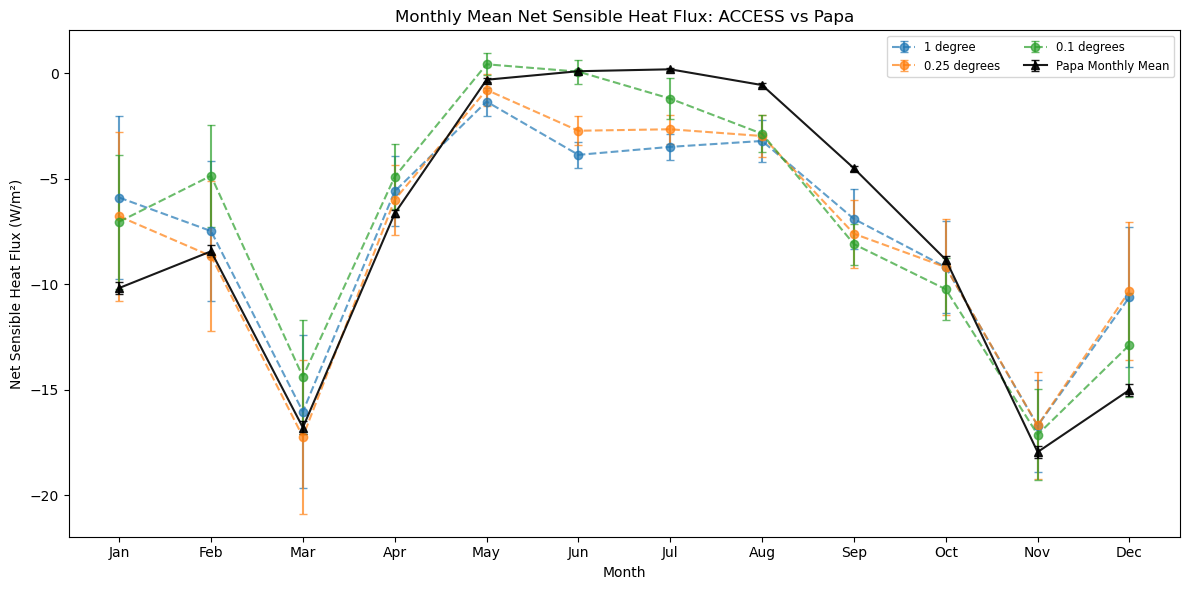

In [11]:
#------------------------------------------------------------------
# PLOT
#------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

exp_titles = {
    '1deg_jra55_iaf_omip2_cycle6': '1 degree',
    '025deg_jra55_iaf_omip2_cycle6': '0.25 degrees',
    '01deg_jra55v140_iaf_cycle4': '0.1 degrees'
}

# Plot ACCESS sensible heat flux for each resolution
for exp_name, data_dict in exp_heat_flux.items():
    monthly_mean = data_dict['monthly_mean']
    label = exp_titles.get(exp_name, exp_name)

    monthly_sem = data_dict["monthly_sem"]
    ax.errorbar(
    monthly_mean["month"],
    monthly_mean.values,
    yerr=monthly_sem.values,
    marker="o",
    linestyle="--",
    alpha=0.7,
    capsize=3,
    label=label
)

# Plot Papa sensible heat flux climatology
papa_mean_1d = papa_monthly_mean.isel(depth=0, lat=0, lon=0)
papa_sem_1d  = papa_monthly_sem.isel(depth=0, lat=0, lon=0)

ax.errorbar(
    papa_mean_1d["month"],
    -1*papa_mean_1d.values,
    yerr=papa_sem_1d.values,
    color="black",
    marker="^",
    linestyle="-",
    alpha=0.9,
    capsize=3,
    label="Papa Monthly Mean"
)

ax.set_xlabel('Month')
ax.set_ylabel('Net Sensible Heat Flux (W/m²)')
ax.set_title('Monthly Mean Net Sensible Heat Flux: ACCESS vs Papa')
ax.set_xticks(np.arange(1, 13))
ax.set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

ax.legend(ncol=2, fontsize='small', loc='best')
plt.tight_layout()
plt.show()
